# Baseline mdel evaluation

In [22]:
import os
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
from pathlib import Path
import torch
import torch.nn as nn
from tqdm import tqdm


In [11]:
PROJECT_ROOT = Path('..').resolve()

MEL_PATH = os.path.join(PROJECT_ROOT, "data/processed/mel_spectrograms")
MODEL_PATH = os.path.join(PROJECT_ROOT, "checkpoints/best_model.pth")

GENRES_PATH = os.path.join(PROJECT_ROOT, "data/raw/messy_mashup/genres_stems")

print(f"Project Root: {PROJECT_ROOT}")
print(f"Mel Spectrograms Path: {MEL_PATH}")
print(f"Model Path: {MODEL_PATH}")
print(f"Genres Path: {GENRES_PATH}")

Project Root: /home/saber/IITM/DL-GenAI-Project
Mel Spectrograms Path: /home/saber/IITM/DL-GenAI-Project/data/processed/mel_spectrograms
Model Path: /home/saber/IITM/DL-GenAI-Project/checkpoints/best_model.pth
Genres Path: /home/saber/IITM/DL-GenAI-Project/data/raw/messy_mashup/genres_stems


In [12]:
import pandas as pd

train_df = pd.read_csv(os.path.join(PROJECT_ROOT, "data/splits/train.csv"))

labels = sorted(train_df["label"].unique())
idx_to_label = {i: label for i, label in enumerate(labels)}

idx_to_label

{0: 'blues',
 1: 'classical',
 2: 'country',
 3: 'disco',
 4: 'hiphop',
 5: 'jazz',
 6: 'mashup',
 7: 'metal',
 8: 'pop',
 9: 'reggae',
 10: 'rock'}

In [13]:
class CNNModel(nn.Module):

    def __init__(self, num_classes):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((4,4))
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*4*4, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_classes = len(idx_to_label)

model = CNNModel(num_classes).to(device)

model.load_state_dict(torch.load(MODEL_PATH, map_location=device))

model.eval()

/tmp/ipykernel_48359/3619724033.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(MODEL_PATH, map_location=device))


CNNModel(
  (conv): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): AdaptiveAvgPool2d(output_size=(4, 4))
  )
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1024, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=11, bias=True)
  )
)

In [15]:
def fix_length(mel, target_length=1300):

    if mel.shape[1] < target_length:
        pad_width = target_length - mel.shape[1]
        mel = np.pad(mel, ((0,0),(0,pad_width)), mode='constant')
    else:
        mel = mel[:, :target_length]

    return mel


def preprocess(file):

    y, sr = librosa.load(file, sr=22050)

    mel = librosa.feature.melspectrogram(y=y, sr=sr)
    mel = librosa.power_to_db(mel)

    mel = fix_length(mel)

    mel = (mel - mel.mean()) / (mel.std() + 1e-6)

    mel = torch.from_numpy(mel).float().unsqueeze(0).unsqueeze(0)

    return mel.to(device)

In [16]:
sample_file = os.path.join(
    GENRES_PATH,
    "jazz",
    "jazz.00000",
    "bass.wav"
)

sample_file

'/home/saber/IITM/DL-GenAI-Project/data/raw/messy_mashup/genres_stems/jazz/jazz.00000/bass.wav'

In [17]:
x = preprocess(sample_file)

with torch.no_grad():
    out = model(x)

pred = out.argmax(dim=1).item()

print("Predicted:", idx_to_label[pred])

/home/saber/IITM/DL-GenAI-Project/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Predicted: jazz


In [18]:
probs = torch.softmax(out, dim=1).cpu().numpy()[0]

for i, p in enumerate(probs):
    print(f"{idx_to_label[i]}: {p:.4f}")

blues: 0.1019
classical: 0.1867
country: 0.2227
disco: 0.0014
hiphop: 0.0307
jazz: 0.3709
mashup: 0.0000
metal: 0.0006
pop: 0.0274
reggae: 0.0175
rock: 0.0402


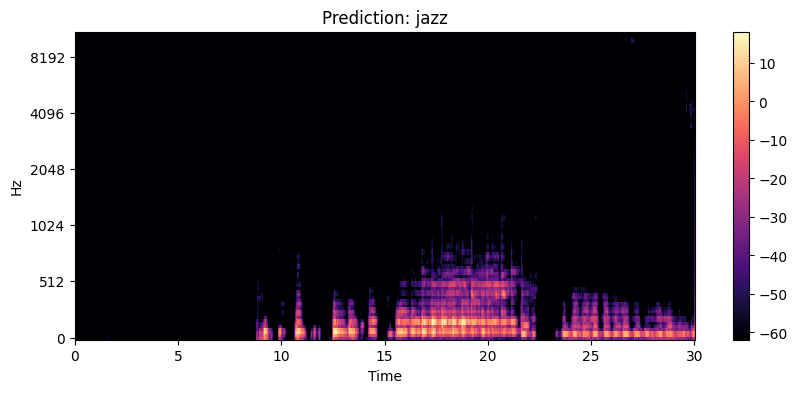

In [19]:
y, sr = librosa.load(sample_file)

mel = librosa.feature.melspectrogram(y=y, sr=sr)
mel_db = librosa.power_to_db(mel)

plt.figure(figsize=(10,4))
librosa.display.specshow(mel_db, sr=sr, x_axis="time", y_axis="mel")
plt.colorbar()

plt.title(f"Prediction: {idx_to_label[pred]}")

plt.show()

In [20]:
import random

genres = os.listdir(GENRES_PATH)

for _ in range(5):

    genre = random.choice(genres)
    track = random.choice(os.listdir(os.path.join(GENRES_PATH, genre)))
    stem = random.choice(os.listdir(os.path.join(GENRES_PATH, genre, track)))

    file = os.path.join(GENRES_PATH, genre, track, stem)

    x = preprocess(file)

    with torch.no_grad():
        pred = model(x).argmax(dim=1).item()

    print(f"True: {genre} | Pred: {idx_to_label[pred]}")

True: reggae | Pred: blues
True: disco | Pred: disco
True: disco | Pred: disco
True: hiphop | Pred: pop
True: country | Pred: country


In [23]:
# classification_report
from sklearn.metrics import classification_report
y_true = []
y_pred = []

for genre in tqdm(genres):
    genre_path = os.path.join(GENRES_PATH, genre)
    for track in os.listdir(genre_path):
        track_path = os.path.join(genre_path, track)
        for stem in os.listdir(track_path):
            file = os.path.join(track_path, stem)

            x = preprocess(file)

            with torch.no_grad():
                pred = model(x).argmax(dim=1).item()

            y_true.append(genre)
            y_pred.append(idx_to_label[pred])
print(classification_report(y_true, y_pred, target_names=labels))

100%|██████████| 10/10 [04:27<00:00, 26.79s/it]

              precision    recall  f1-score   support

       blues       0.61      0.42      0.50       400
   classical       0.78      0.82      0.80       400
     country       0.46      0.63      0.53       400
       disco       0.59      0.46      0.52       400
      hiphop       0.63      0.59      0.61       400
        jazz       0.59      0.71      0.64       400
      mashup       0.00      0.00      0.00         0
       metal       0.71      0.86      0.78       400
         pop       0.57      0.53      0.55       400
      reggae       0.54      0.56      0.55       400
        rock       0.47      0.35      0.40       400

    accuracy                           0.59      4000
   macro avg       0.54      0.54      0.53      4000
weighted avg       0.59      0.59      0.59      4000




/home/saber/IITM/DL-GenAI-Project/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/saber/IITM/DL-GenAI-Project/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/saber/IITM/DL-GenAI-Project/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitaliz

# finetune mix model